In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

LR = 1e-3
EPOCHS = 50
BS = 300

print("[INFO] Loading data...")
df = pd.read_csv("train.csv")
data = df.drop(columns='label').to_numpy() / 255.
labels = df['label'].to_numpy()

[INFO] Loading data...


In [2]:
print("Data shape: ", data.shape)
print("Labels shape: ", labels.shape)

Data shape:  (42000, 784)
Labels shape:  (42000,)


In [3]:
print('[INFO] Reshaping data...')
data = data.reshape((data.shape[0], 28, 28, 1))

[INFO] Reshaping data...


In [4]:
data.shape

(42000, 28, 28, 1)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, stratify=labels, random_state=42
)

print("[INFO] Building model...")
model = keras.models.Sequential([
    keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Dropout(0.25),
    keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Dropout(0.25),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

[INFO] Building model...


In [6]:
print("[INFO] Compiling model...")
adam = keras.optimizers.Adam(lr=LR, decay=LR / EPOCHS)
model.compile(loss="sparse_categorical_crossentropy", optimizer=adam, metrics=["accuracy"])

[INFO] Compiling model...


In [7]:
# print("[INFO] Training model...")
# history = model.fit(
#     X_train, y_train,
#     batch_size=BS,
#     validation_data=(X_test,y_test),
#     epochs=EPOCHS,
#     callbacks=[keras.callbacks.EarlyStopping(patience=5)]
# )

In [8]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=10,
    zoom_range = 0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)


datagen.fit(X_train)

In [9]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BS),
    epochs=EPOCHS,
    validation_data=(X_test,y_test),
    steps_per_epoch=X_train.shape[0] // BS, 
    callbacks=[keras.callbacks.EarlyStopping(patience=5)]
)

Epoch 1/50
112/112 [==============================] - 22s 198ms/step - loss: 0.8550 - accuracy: 0.7258 - val_loss: 0.1430 - val_accuracy: 0.9600
Epoch 2/50
112/112 [==============================] - 26s 230ms/step - loss: 0.2804 - accuracy: 0.9147 - val_loss: 0.0947 - val_accuracy: 0.9715
Epoch 3/50
112/112 [==============================] - 21s 187ms/step - loss: 0.1994 - accuracy: 0.9387 - val_loss: 0.0737 - val_accuracy: 0.9775
Epoch 4/50
112/112 [==============================] - 20s 176ms/step - loss: 0.1599 - accuracy: 0.9504 - val_loss: 0.0593 - val_accuracy: 0.9808
Epoch 5/50
112/112 [==============================] - 20s 175ms/step - loss: 0.1314 - accuracy: 0.9601 - val_loss: 0.0510 - val_accuracy: 0.9851
Epoch 6/50
112/112 [==============================] - 20s 177ms/step - loss: 0.1145 - accuracy: 0.9640 - val_loss: 0.0466 - val_accuracy: 0.9858
Epoch 7/50
112/112 [==============================] - 20s 176ms/step - loss: 0.1009 - accuracy: 0.9682 - val_loss: 0.0381 - val_ac

[INFO] Plotting loss curve...


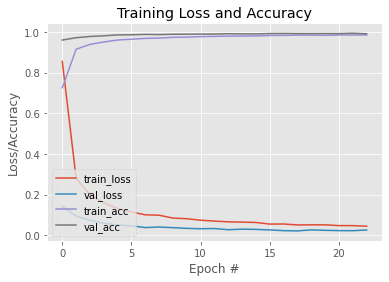

In [11]:
print("[INFO] Plotting loss curve...")
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, len(history.history["loss"])), history.history["loss"], label="train_loss")
plt.plot(np.arange(0, len(history.history["loss"])), history.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, len(history.history["loss"])), history.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, len(history.history["loss"])), history.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")

In [12]:
predictions = model.predict_classes(X_test)
print(classification_report(y_test, predictions))

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       826
           1       1.00      0.99      0.99       937
           2       0.99      1.00      0.99       835
           3       0.99      0.99      0.99       870
           4       1.00      0.99      0.99       814
           5       0.99      0.99      0.99       759
           6       0.99      1.00      1.00       828
           7       1.00      0.98      0.99       880
           8       0.99      0.98      0.98       813
           9       0.98      0.99      0.99       838

    accuracy                           0.99      8400
   macro avg    

In [13]:
print("[INFO] Loading test data...")
test_df = pd.read_csv("test.csv")

test_data = test_df.to_numpy() / 255.
test_data = test_data.reshape((test_data.shape[0], 28, 28, 1))

[INFO] Loading test data...


In [14]:
test_predictions = model.predict_classes(test_data)

In [15]:
submission = pd.DataFrame({
    'ImageId': test_df.index + 1,
    'Label': test_predictions
})

In [16]:
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [17]:
submission.to_csv('submission.csv', index=False)